# FrozenLake Sarsa 구현
**알고리즘 5-1 (시간차 TD 학습)** 기반 Sarsa (on-policy TD 제어)

In [1]:
!pip install gymnasium -q

In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings("ignore")

# 나눔고딕 설치
!apt-get install -y fonts-nanum -q

# 설치된 폰트를 matplotlib에 강제 등록
import subprocess, os
nanum_files = subprocess.getoutput("find /usr/share/fonts -name NanumGothic.ttf").strip().split()
for f_path in nanum_files:
    fm.fontManager.addfont(f_path)

# 캐시 갱신 후 적용
fm._load_fontmanager(try_read_cache=False)
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

# 확인
found = [f.name for f in fm.fontManager.ttflist if "Nanum" in f.name]
print("등록된 Nanum 폰트:", found[:3])
print("현재 폰트:", plt.rcParams["font.family"])


Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 5 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (6,707 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
등록된 Nanum 폰트: ['NanumGothic']
현재 폰트: ['NanumGothic']


## 환경 설정 및 하이퍼파라미터

In [3]:
env = gym.make("FrozenLake-v1", is_slippery=True)
n_states  = env.observation_space.n
n_actions = env.action_space.n

EPISODES = 10000
rho      = 0.1
gamma    = 0.99
epsilon  = 0.1

print(f"상태 수: {n_states}, 행동 수: {n_actions}")
print(f"rho={rho}, gamma={gamma}, epsilon={epsilon}, 에피소드={EPISODES}")


상태 수: 16, 행동 수: 4
rho=0.1, gamma=0.99, epsilon=0.1, 에피소드=10000


## Sarsa 학습 (알고리즘 5-1 적용)

In [4]:
# Q 테이블 초기화 (알고리즘 5-1: v(s)=0 -> Q(s,a)=0)
Q = np.zeros((n_states, n_actions))

def select_action(s, eps=epsilon):
    if np.random.rand() < eps:
        return env.action_space.sample()
    return int(np.argmax(Q[s]))

reward_history = []
success_rate   = []

for ep in range(EPISODES):
    s, _ = env.reset()
    a = select_action(s)          # 5번 줄: 행동 a 선택
    total_reward = 0

    while True:
        # 6번 줄: a 실행 -> s', r 획득
        s_next, r, terminated, truncated, _ = env.step(a)
        done = terminated or truncated

        a_next = select_action(s_next)  # Sarsa: 다음 행동 미리 선택

        # 7번 줄: Q(s,a) = Q(s,a) + rho*((r + gamma*Q(s',a')) - Q(s,a))
        Q[s, a] += rho * ((r + gamma * Q[s_next, a_next]) - Q[s, a])

        total_reward += r
        s = s_next   # 8번 줄: s = s'
        a = a_next

        if done:
            break

    reward_history.append(total_reward)
    if (ep + 1) % 100 == 0:
        success_rate.append(np.mean(reward_history[-100:]))

env.close()
print("학습 완료!")
print(f"최근 1000 에피소드 성공률: {np.mean(reward_history[-1000:]):.3f}")


학습 완료!
최근 1000 에피소드 성공률: 0.392


## 결과 출력

In [5]:
action_names = ["left", "down", "right", "up"]
holes = {5, 7, 11, 12}

print("[학습된 Q 테이블]")
print(f"{chr(32)*4}  " + "  ".join(f"{a:>6}" for a in action_names))
for s in range(n_states):
    vals = "  ".join(f"{Q[s,a]:6.3f}" for a in range(n_actions))
    best = action_names[np.argmax(Q[s])]
    print(f"  s{s:02d}  {vals}   best: {best}")

print("[최적 정책 그리드 (4x4)]")
sym = ["<","v",">","^"]
grid = [sym[np.argmax(Q[s])] for s in range(n_states)]
for r in range(4):
    row = ""
    for c in range(4):
        s = r*4+c
        if s==0: row+=" S "
        elif s==15: row+=" G "
        elif s in holes: row+=" H "
        else: row+=f" {grid[s]} "
    print(row)


[학습된 Q 테이블]
        left    down   right      up
  s00   0.299   0.254   0.275   0.276   best: left
  s01   0.140   0.189   0.127   0.231   best: up
  s02   0.214   0.156   0.149   0.154   best: left
  s03   0.019   0.097   0.000   0.071   best: down
  s04   0.328   0.209   0.222   0.230   best: left
  s05   0.000   0.000   0.000   0.000   best: left
  s06   0.220   0.154   0.132   0.079   best: left
  s07   0.000   0.000   0.000   0.000   best: left
  s08   0.250   0.252   0.165   0.393   best: up
  s09   0.333   0.576   0.324   0.247   best: down
  s10   0.669   0.330   0.249   0.149   best: left
  s11   0.000   0.000   0.000   0.000   best: left
  s12   0.000   0.000   0.000   0.000   best: left
  s13   0.423   0.450   0.628   0.372   best: right
  s14   0.533   0.694   0.695   0.778   best: up
  s15   0.000   0.000   0.000   0.000   best: left
[최적 정책 그리드 (4x4)]
 S  ^  <  v 
 <  H  <  H 
 ^  v  <  H 
 H  >  ^  G 


## 시각화

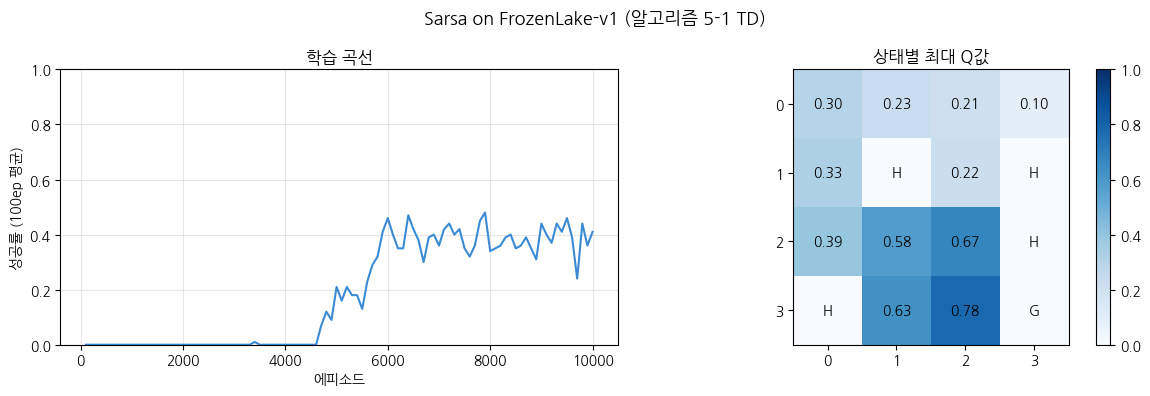

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Sarsa on FrozenLake-v1 (알고리즘 5-1 TD)", fontsize=13)

axes[0].plot(range(100, EPISODES+1, 100), success_rate, color="#3B8BD4")
axes[0].set_xlabel("에피소드")
axes[0].set_ylabel("성공률 (100ep 평균)")
axes[0].set_title("학습 곡선")
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)

q_max = np.max(Q, axis=1).reshape(4,4)
im = axes[1].imshow(q_max, cmap="Blues", vmin=0, vmax=1)
axes[1].set_title("상태별 최대 Q값")
axes[1].set_xticks(range(4))
axes[1].set_yticks(range(4))
for ri in range(4):
    for ci in range(4):
        s = ri*4+ci
        lbl = f"{q_max[ri,ci]:.2f}"
        if s in holes: lbl="H"
        elif s==15: lbl="G"
        axes[1].text(ci, ri, lbl, ha="center", va="center", fontsize=10)
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()
